In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from datetime import datetime

In [3]:
df = pd.read_csv("final_stock_prices.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1972-06-01 00:00:00-04:00,1.224211,1.224211,1.224211,1.224211,0,0.0,0.0
1,1972-06-02 00:00:00-04:00,1.218877,1.218877,1.218877,1.218877,0,0.0,0.0
2,1972-06-05 00:00:00-04:00,1.194874,1.194874,1.194874,1.194874,0,0.0,0.0
3,1972-06-06 00:00:00-04:00,1.130862,1.130862,1.130862,1.130862,0,0.0,0.0
4,1972-06-07 00:00:00-04:00,1.117527,1.117527,1.117527,1.117527,0,0.0,0.0


In [4]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1972-06-01 00:00:00-04:00,1.224211,1.224211,1.224211,1.224211,0,0.0,0.0
1,1972-06-02 00:00:00-04:00,1.218877,1.218877,1.218877,1.218877,0,0.0,0.0
2,1972-06-05 00:00:00-04:00,1.194874,1.194874,1.194874,1.194874,0,0.0,0.0
3,1972-06-06 00:00:00-04:00,1.130862,1.130862,1.130862,1.130862,0,0.0,0.0
4,1972-06-07 00:00:00-04:00,1.117527,1.117527,1.117527,1.117527,0,0.0,0.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13556 entries, 0 to 13555
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          13556 non-null  str    
 1   Open          13556 non-null  float64
 2   High          13556 non-null  float64
 3   Low           13556 non-null  float64
 4   Close         13556 non-null  float64
 5   Volume        13556 non-null  int64  
 6   Dividends     13556 non-null  float64
 7   Stock Splits  13556 non-null  float64
dtypes: float64(6), int64(1), str(1)
memory usage: 847.4 KB


In [7]:
#Observation: Date needs to be transformed.

In [9]:
#Statistical Summary
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,13556.000000,13556.000000,13556.000000,13556.000000,1.355600e+04,13556.000000,13556.000000
mean,42.045176,42.491807,41.589092,42.052074,4.943473e+06,0.002528,0.000746
std,64.495773,65.145667,63.820291,64.512382,4.395001e+06,0.030580,0.038035
min,0.381399,0.389401,0.376065,0.376065,0.000000e+00,0.000000,0.000000
25%,2.808826,2.846430,2.771523,2.808977,2.501578e+06,0.000000,0.000000
50%,19.273532,19.709045,18.799586,19.236960,3.945900e+06,0.000000,0.000000
75%,47.769938,48.129418,47.365409,47.799907,6.005802e+06,0.000000,0.000000
max,385.633318,386.631101,379.896061,384.036896,9.033690e+07,0.820000,3.000000


### Data Cleaning and Data Transformation

In [11]:
missing = df.isnull().sum()
print(missing)

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


In [12]:
#Data Cleaning

In [15]:
df['Date'] = pd.to_datetime(df['Date'],utc = True).dt.tz_convert(None) 
#Date column converted to datetime format

In [17]:
df = df.sort_values(by = 'Date').reset_index(drop = True)
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1972-06-01 04:00:00,1.224211,1.224211,1.224211,1.224211,0,0.0,0.0
1,1972-06-02 04:00:00,1.218877,1.218877,1.218877,1.218877,0,0.0,0.0
2,1972-06-05 04:00:00,1.194874,1.194874,1.194874,1.194874,0,0.0,0.0
3,1972-06-06 04:00:00,1.130862,1.130862,1.130862,1.130862,0,0.0,0.0
4,1972-06-07 04:00:00,1.117527,1.117527,1.117527,1.117527,0,0.0,0.0


In [18]:
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

In [19]:
if duplicates>0:
    df.drop_duplicates()

In [20]:
#check negative price
negative_price = (df[['Open','High','Low','Close']]<0).sum().sum()
negative_price

np.int64(0)

In [21]:
#create useful columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day_Of_Week'] = df['Date'].dt.day_name()
df['Daily_Return'] = df['Close'].pct_change()*100

In [29]:
df['Price_Range'] = df['High']-df['Low']

In [30]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Year,Month,Day_Of_Week,Daily_Return,Price_Range
0,1972-06-01 04:00:00,1.224211,1.224211,1.224211,1.224211,0,0.0,0.0,1972,6,Thursday,NaN,0.0
1,1972-06-02 04:00:00,1.218877,1.218877,1.218877,1.218877,0,0.0,0.0,1972,6,Friday,-0.435682,0.0
2,1972-06-05 04:00:00,1.194874,1.194874,1.194874,1.194874,0,0.0,0.0,1972,6,Monday,-1.969332,0.0
3,1972-06-06 04:00:00,1.130862,1.130862,1.130862,1.130862,0,0.0,0.0,1972,6,Tuesday,-5.357164,0.0
4,1972-06-07 04:00:00,1.117527,1.117527,1.117527,1.117527,0,0.0,0.0,1972,6,Wednesday,-1.179230,0.0


### Data Visualization

In [25]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (15,10)

#### Histogram plot

Closing Price Histogram: Shows how stock prices distributed over 50 years
helps understand volatility and normality of returns
shows how actively the stock was traded on different days
Log transformation makes highly skewed volume data more interpretable


/var/folders/sl/ylx38ztj4wn7n_b5mssc94kr0000gn/T/ipykernel_50383/4084872736.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/sl/ylx38ztj4wn7n_b5mssc94kr0000gn/T/ipykernel_50383/4084872736.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


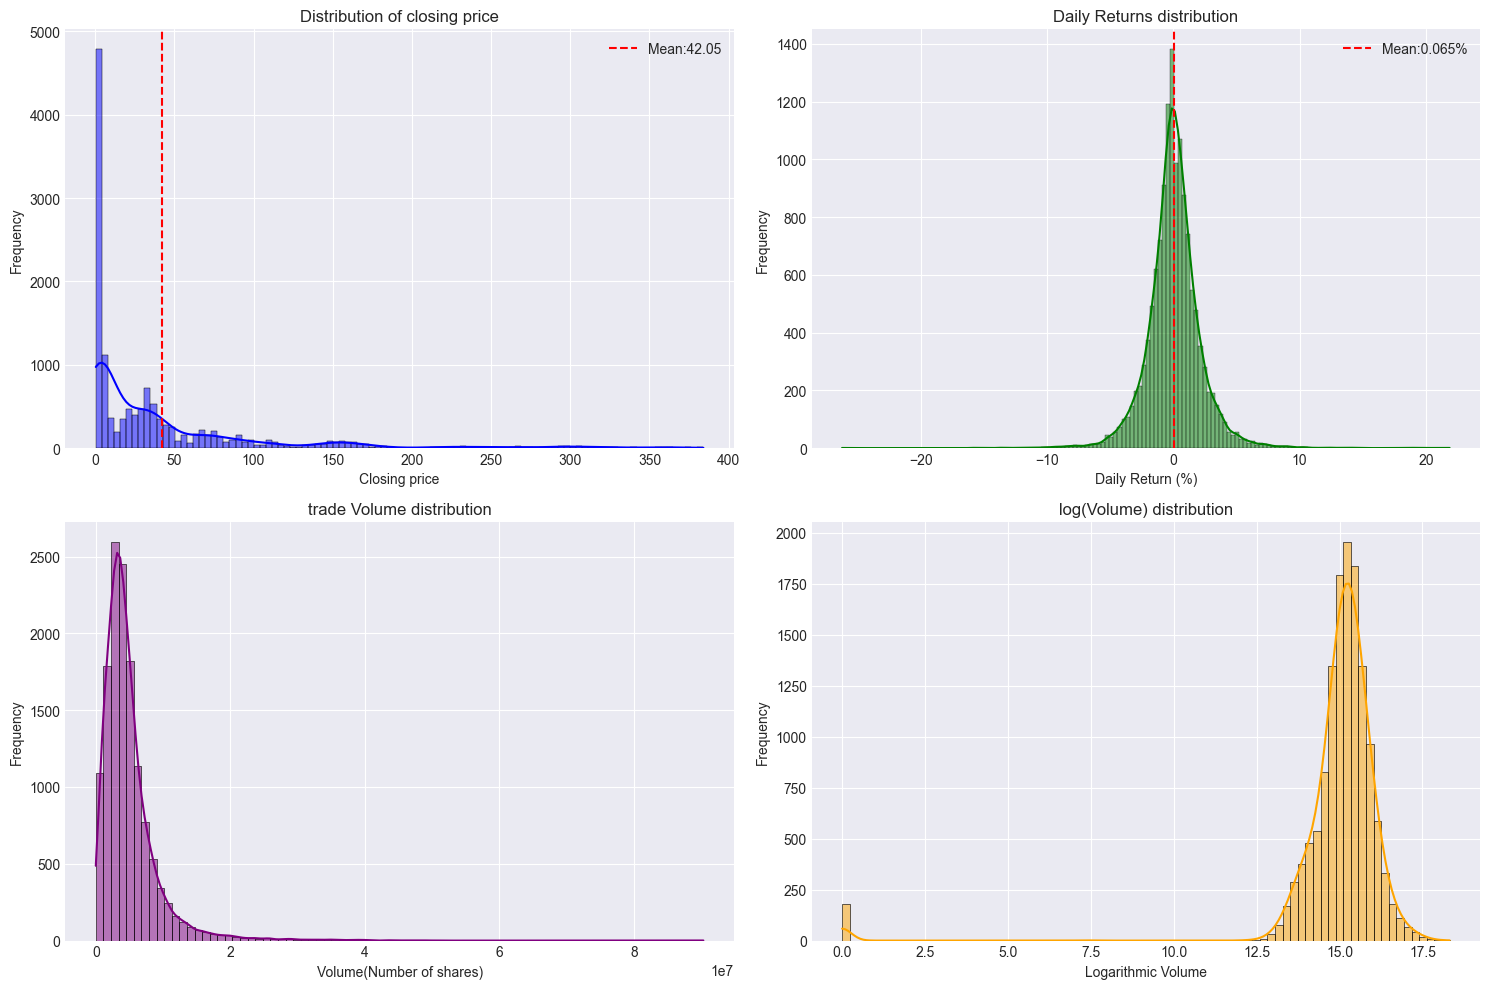

In [37]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
sns.histplot(data = df, x = 'Close', bins= 100, kde = True, color = 'blue')
plt.title("Distribution of closing price")
plt.xlabel("Closing price")
plt.ylabel('Frequency')
plt.axvline(df['Close'].mean(), color = 'red', linestyle = '--',label = f"Mean:{df['Close'].mean():.2f}")
plt.legend()
print('Closing Price Histogram: Shows how stock prices distributed over 50 years')


#Daily return distribution 
plt.subplot(2,2,2)
sns.histplot(data = df, x = 'Daily_Return', bins = 150, kde = True, color = 'green')
plt.title('Daily Returns distribution')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.axvline(df['Daily_Return'].mean(), color = 'red', linestyle = '--', label = f'Mean:{df['Daily_Return'].mean():.3f}%')
plt.legend()
print('helps understand volatility and normality of returns')

#Trading Volume Distribution
plt.subplot(2,2,3)
sns.histplot(data = df, x = 'Volume', bins = 80, kde = True, color = 'purple')
plt.title('trade Volume distribution')
plt.xlabel('Volume(Number of shares)')
plt.ylabel('Frequency')
plt.legend()
print('shows how actively the stock was traded on different days')


#log of volume
plt.subplot(2,2,4)
sns.histplot(data = df, x = np.log1p(df['Volume']), bins = 80, kde = True, color = 'orange')
plt.title('log(Volume) distribution')
plt.xlabel('Logarithmic Volume')
plt.ylabel('Frequency')
plt.legend()
print('Log transformation makes highly skewed volume data more interpretable')

plt.tight_layout()
plt.show()

/var/folders/sl/ylx38ztj4wn7n_b5mssc94kr0000gn/T/ipykernel_50383/1360752363.py:15: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/sl/ylx38ztj4wn7n_b5mssc94kr0000gn/T/ipykernel_50383/1360752363.py:15: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


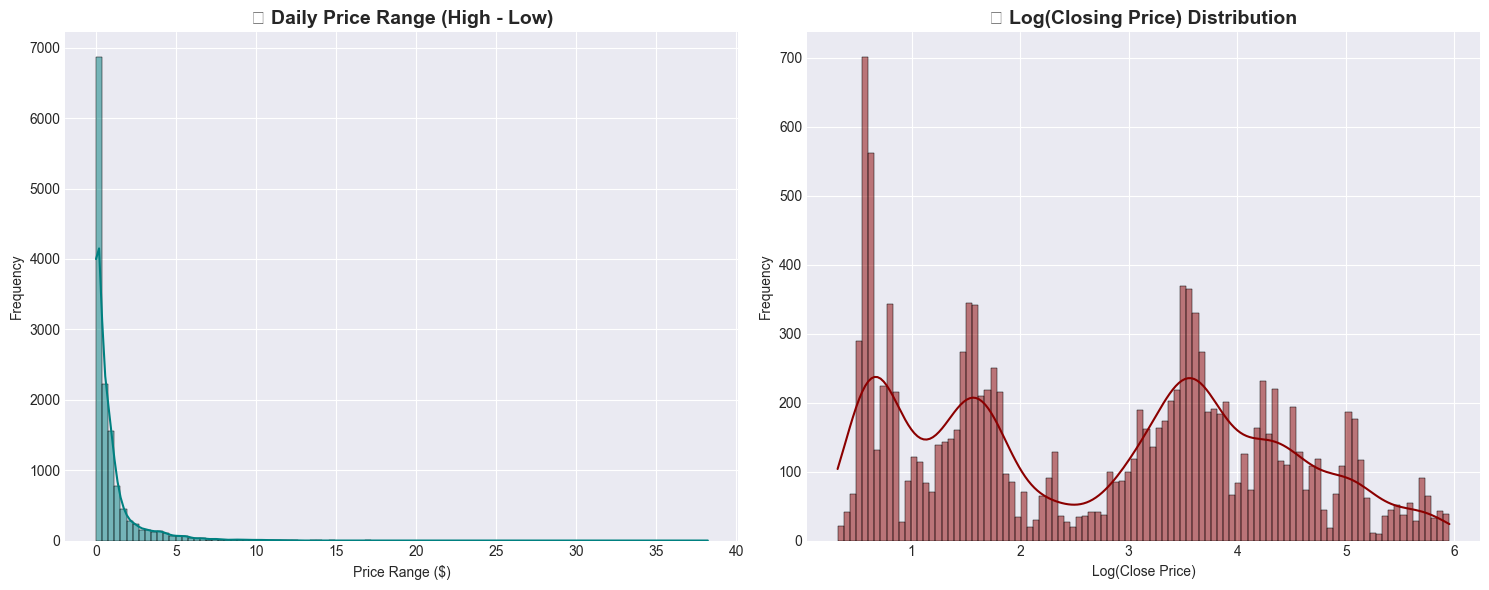

In [38]:
# 5. Daily Price Range (Volatility)
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Price_Range', bins=100, kde=True, color='teal')
plt.title('📏 Daily Price Range (High - Low)', fontsize=14, fontweight='bold')
plt.xlabel('Price Range ($)')
plt.ylabel('Frequency')

# 6. Log of Closing Price
plt.subplot(1, 2, 2)
sns.histplot(data=df, x=np.log1p(df['Close']), bins=100, kde=True, color='darkred')
plt.title('📈 Log(Closing Price) Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Log(Close Price)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Trend and Seasonality

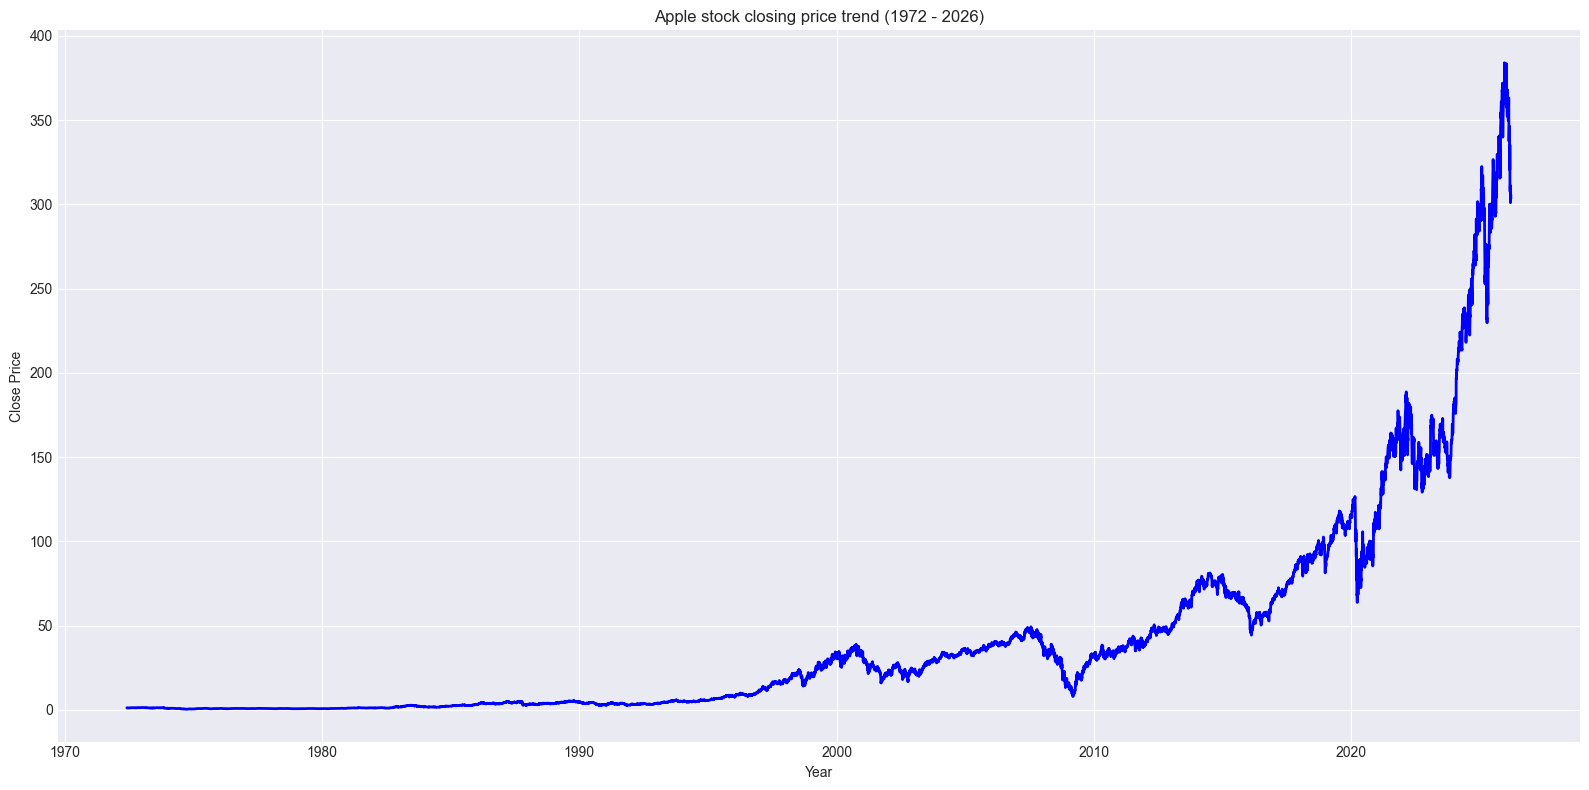

plot 1: shows the log term growth over 54 years


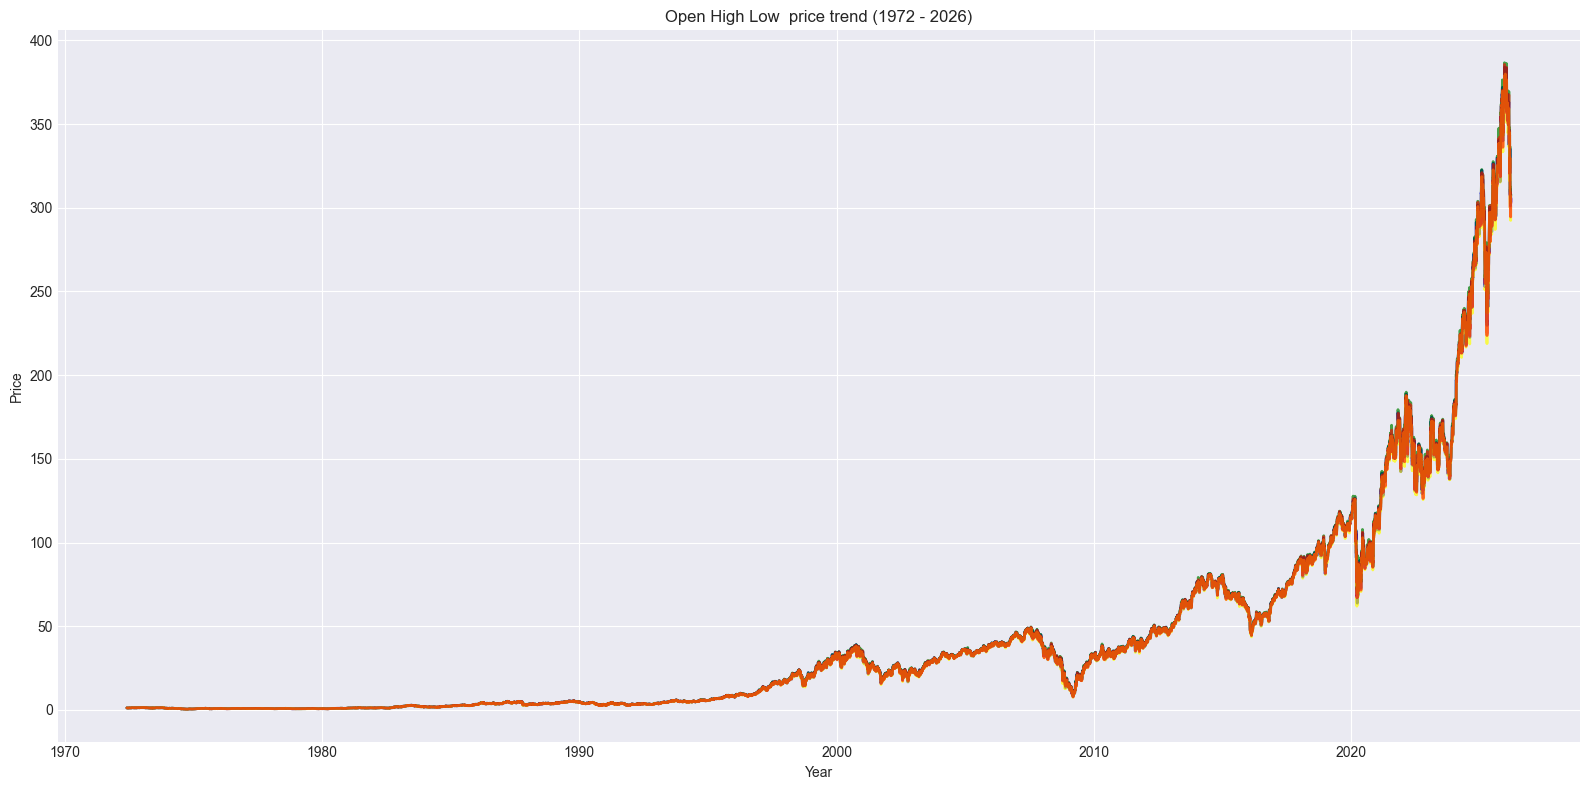

plot 2: OHLC Trend


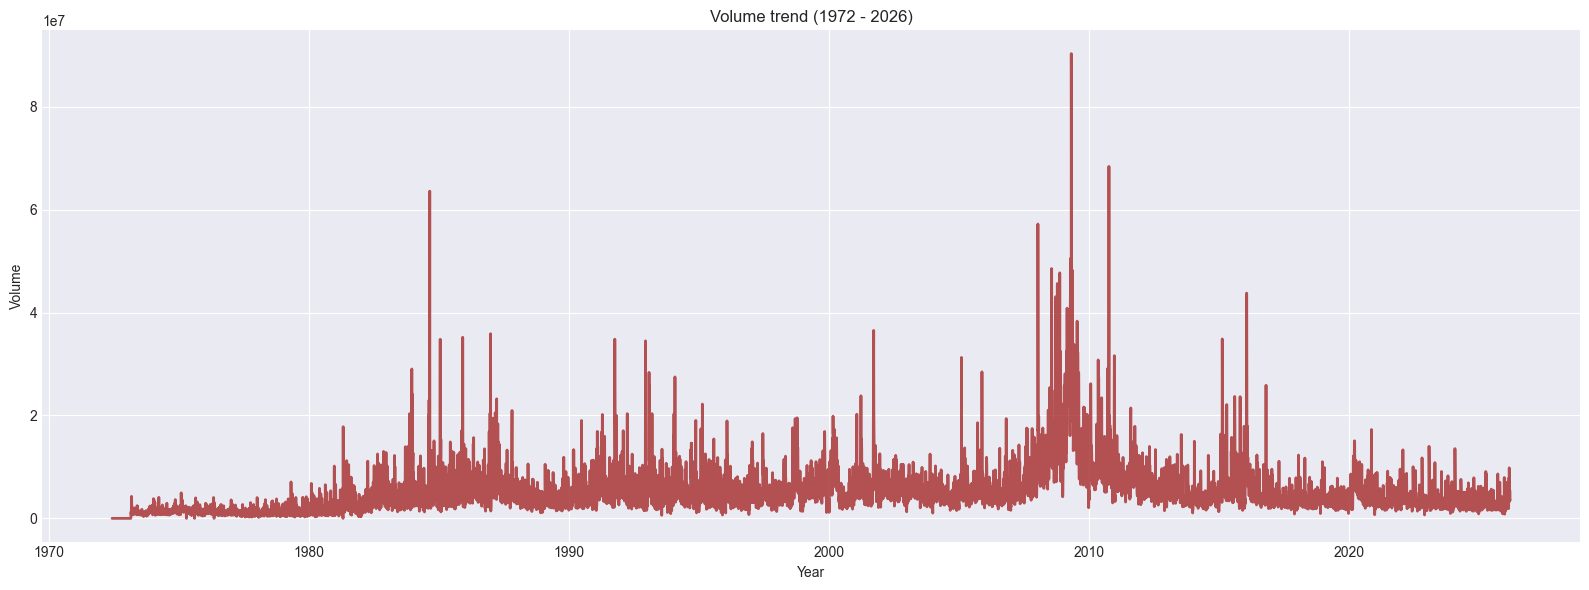

In [61]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize']=(16,10)
plt.rcParams['lines.linewidth'] = 2

plt.figure(figsize=(16,8))
plt.plot(df['Date'],df['Close'], color = 'blue', label = 'Close Price')
plt.title('Apple stock closing price trend (1972 - 2026)')
plt.xlabel('Year')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.savefig('Apple stock closing price trend (1972 - 2026).png')
plt.show()

print('plot 1: shows the log term growth over 54 years')

#OHLC Comparison
plt.figure(figsize=(16,8))
plt.plot(df['Date'],df['Close'], color = 'blue', label = 'Close Price')
plt.plot(df['Date'],df['High'], color = 'green', label = 'High Price',alpha = 0.7)
plt.plot(df['Date'],df['Low'], color = 'yellow', label = 'Low Price', alpha = 0.7)
plt.plot(df['Date'],df['Open'], color = 'red', label = 'Open Price',alpha = 0.6)
plt.title('Open High Low  price trend (1972 - 2026)')
plt.xlabel('Year')
plt.ylabel('Price')
plt.grid(True)
plt.tight_layout()
plt.savefig('OHLC Comparison.png')
plt.show()

print('plot 2: OHLC Trend')
plt.figure(figsize = (16,6))
plt.plot(df['Date'],df['Volume'], color = 'brown', label = 'Open Price',alpha = 0.8)
plt.title('Volume trend (1972 - 2026)')
plt.xlabel('Year')
plt.ylabel('Volume')
plt.tight_layout()
plt.savefig('Volume Trend.png')
plt.show()



##### Moving Average

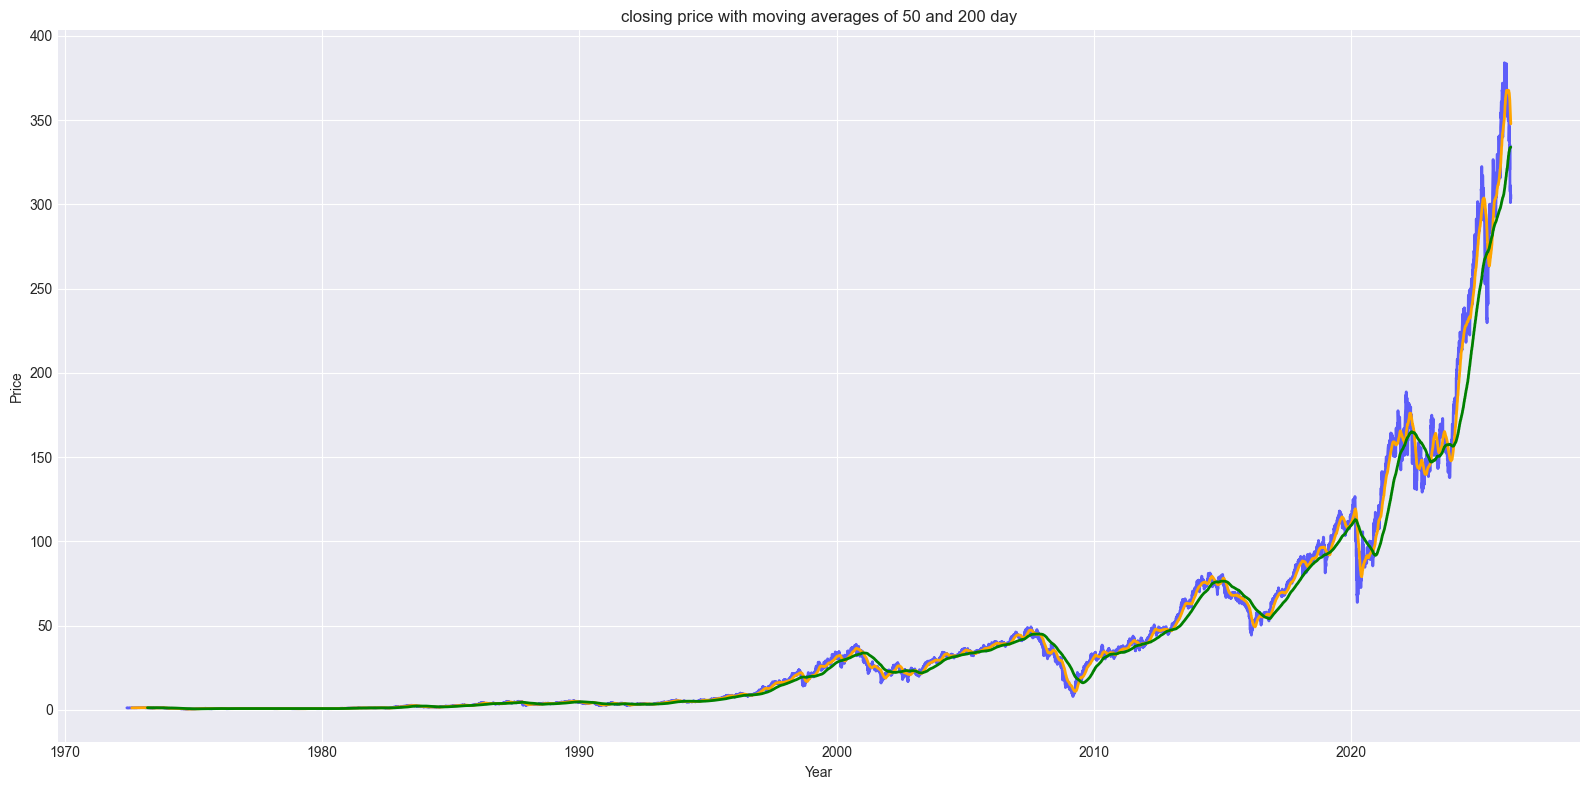

In [59]:
df['MA50'] = df['Close'].rolling(window = 50).mean()
df['MA200'] = df['Close'].rolling(window = 200).mean()

plt.figure(figsize=(16,8))
plt.plot(df['Date'], df['Close'], color = 'blue', label = 'Close Price' , alpha = 0.6 )
plt.plot(df['Date'], df['MA50'], color = 'orange', label = '50 Day MA' , linewidth = 2 )
plt.plot(df['Date'], df['MA200'], color = 'green', label = '200 Day MA' , linewidth = 2 )
plt.title('closing price with moving averages of 50 and 200 day')
plt.xlabel('Year')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('closing price with moving averages of 50 and 200 day.png')
plt.show()

In [46]:
#observation : Golden cross ,death cross

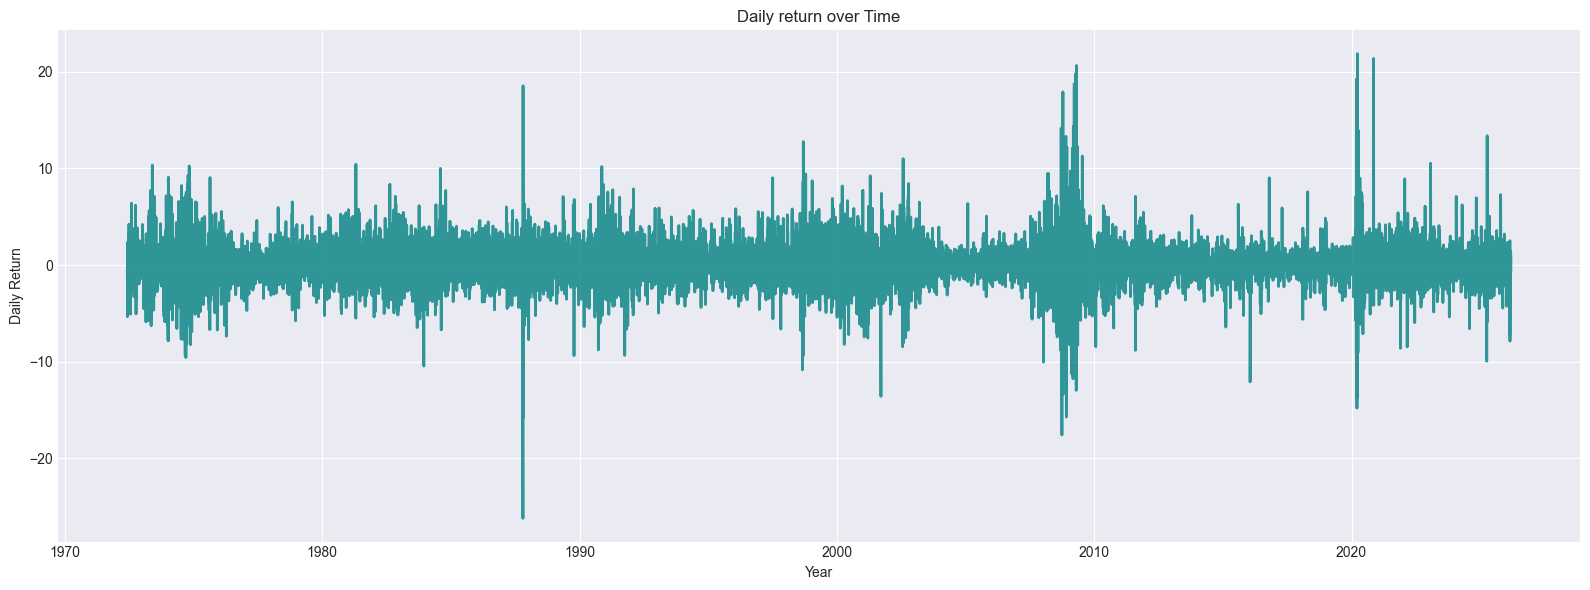

In [58]:
plt.figure(figsize = (16,6))
plt.plot(df['Date'],df['Daily_Return'], color = 'teal', label = 'Daily Return',alpha = 0.8)
plt.title('Daily return over Time')
plt.xlabel('Year')
plt.ylabel('Daily Return')
plt.tight_layout()
plt.savefig('Daily Return.png')
plt.show()

In [50]:
#Observation: Volatility, Tall spikes shows high volatility

In [52]:
df['Cumulative_Return'] = (1+df['Daily_Return']/100).cumprod()

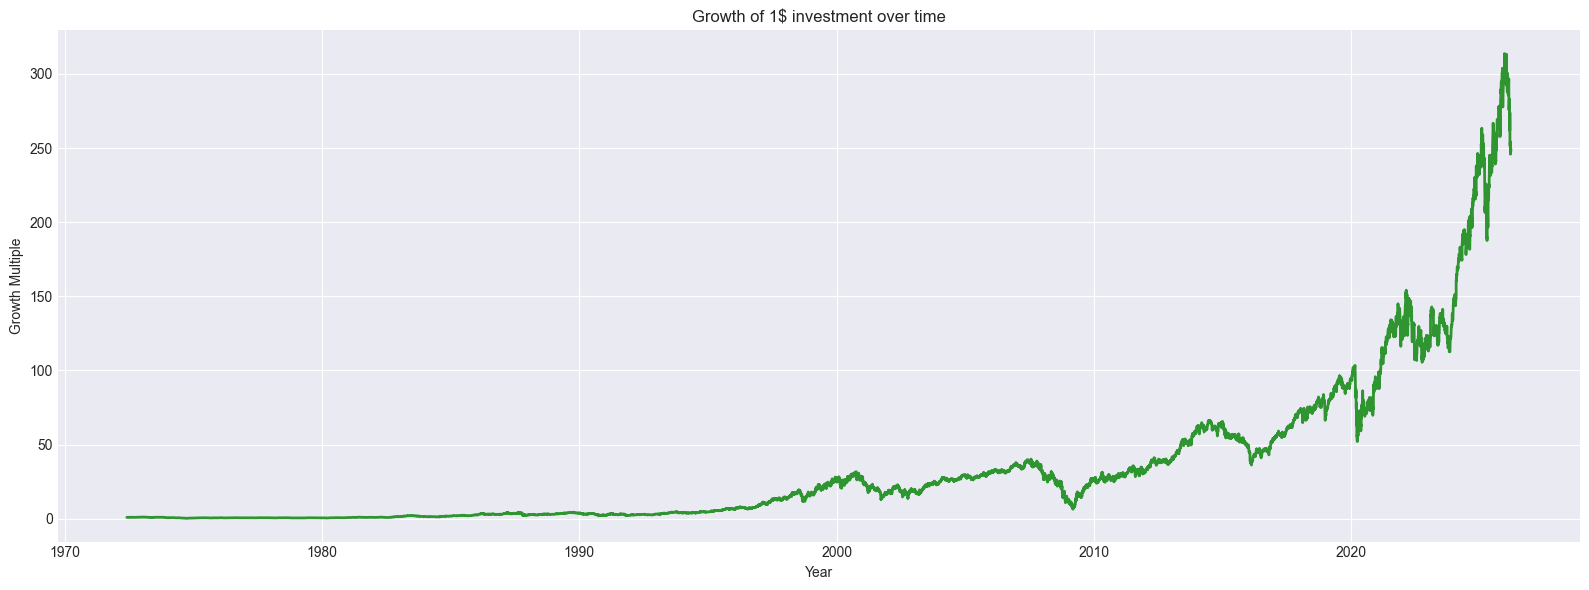

In [57]:
plt.figure(figsize = (16,6))
plt.plot(df['Date'],df['Cumulative_Return'], color = 'green', label = 'Open Price',alpha = 0.8)
plt.title('Growth of 1$ investment over time')
plt.xlabel('Year')
plt.ylabel('Growth Multiple')
plt.tight_layout()
plt.savefig('Growth Multiple.png')
plt.show()

/var/folders/sl/ylx38ztj4wn7n_b5mssc94kr0000gn/T/ipykernel_50383/3342519903.py:11: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/sl/ylx38ztj4wn7n_b5mssc94kr0000gn/T/ipykernel_50383/3342519903.py:12: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.savefig('price+Volume_Combined_Chart.png')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


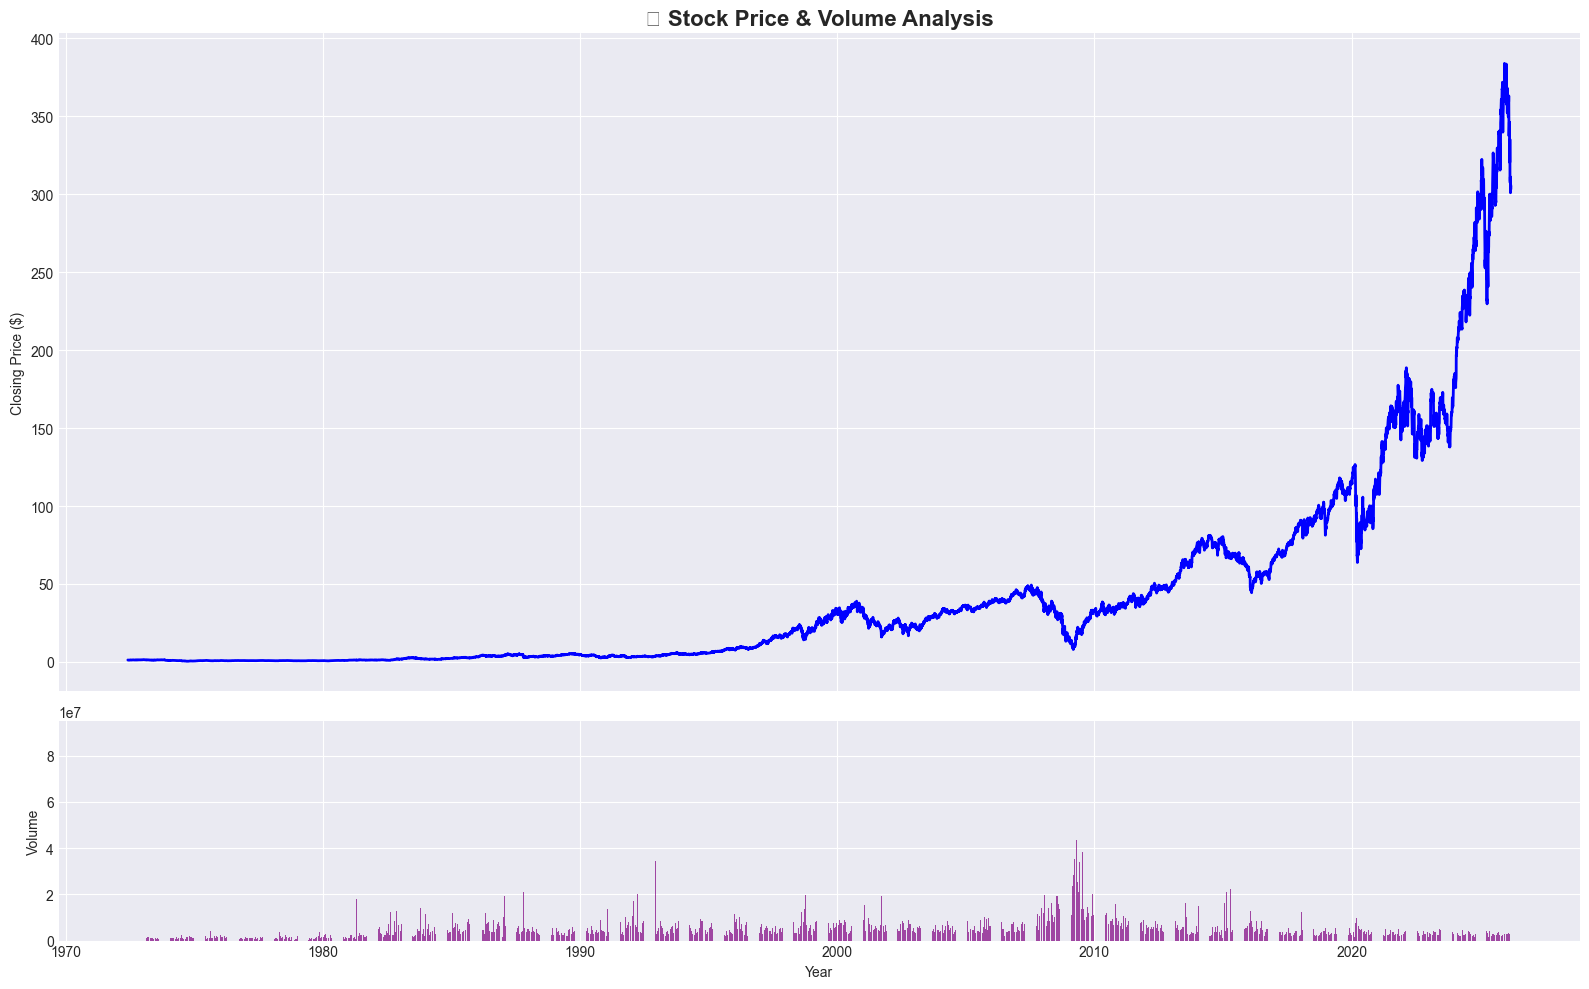

In [56]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(df['Date'], df['Close'], color='blue')
ax1.set_title('📈 Stock Price & Volume Analysis', fontsize=16, fontweight='bold')
ax1.set_ylabel('Closing Price ($)')

ax2.bar(df['Date'], df['Volume'], color='purple', alpha=0.7)
ax2.set_ylabel('Volume')
ax2.set_xlabel('Year')

plt.tight_layout()
plt.savefig('price+Volume_Combined_Chart.png')
plt.show()